In [15]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 15,
      line = dict(color = "black", width = 0.5),
      label = ["STT Датасет", "TTS Датасет", "BONUS Датасет", 'Общий Датасет', "Train", "Test", "Val"],
      color = [
        "rgba(31, 119, 180, 0.8)", "rgba(148, 103, 189, 0.8)", "rgba(23, 190, 207, 0.8)", 
        "rgba(227, 119, 194, 0.8)", 
        "rgba(188, 189, 34, 0.8)", "rgba(255, 127, 14, 0.8)", "rgba(214, 39, 40, 0.8)"
      ]
    ),
    link = dict(
      source = [
        0,
        1, 
        2, 
        3, 3, 3
        ],
      target = [
        3, 
        3, 
        3, 
        4, 5, 6
        ],
      value = [
        8997, 
        13805, 
        15431,
        32107, 3058, 3058,
        ],
      label =  [
        "", "", "", 
        "Train", "Test", "Val"
        ],
      color =  [
        "rgba(31, 119, 180, 0.2)", 
        "rgba(148, 103, 189, 0.2)",  
        "rgba(23, 190, 207, 0.2)", 
        "rgba(188, 189, 34, 0.2)", "rgba(255, 127, 14, 0.2)", "rgba(214, 39, 40, 0.2)"
        ]
  ))])

fig.update_layout(title_text="Распределение данных", font_size=13)
fig.show()

In [16]:
predicts_whisper_large_v3_mansi_v1 = pd.read_csv('predicts_whisper_large_v3_mansi_v1.csv', delimiter="\t")
predicts_whisper_large_v3_mansi_v1['model'] = 'whisper_large_v3_mansi_v1'

predicts_whisper_medium_mansi_v1 = pd.read_csv('predicts_whisper_medium_mansi_v1.csv', delimiter="\t")
predicts_whisper_medium_mansi_v1['model'] = 'whisper_medium_mansi_v1'

predicts_whisper_small_mansi_v1 = pd.read_csv('predicts_whisper_small_mansi_v1.csv', delimiter="\t")
predicts_whisper_small_mansi_v1['model'] = 'whisper_small_mansi_v1'

predicts_whisper_small_mansi_v2 = pd.read_csv('predicts_whisper_small_mansi_v2.csv', delimiter="\t")
predicts_whisper_small_mansi_v2['model'] = 'whisper_small_mansi_v2'

predicts_whisper_small_mansi_v3_synth = pd.read_csv('predicts_whisper_small_mansi_v3_synth.csv', delimiter="\t")
predicts_whisper_small_mansi_v3_synth['model'] = 'whisper_small_mansi_v3'

In [17]:
orig_dataset = pd.concat([
    predicts_whisper_large_v3_mansi_v1, 
    predicts_whisper_medium_mansi_v1, 
    predicts_whisper_small_mansi_v1,
    predicts_whisper_small_mansi_v2,
    predicts_whisper_small_mansi_v3_synth
    ], ignore_index=True)

dataset = orig_dataset[orig_dataset['cer'] < 100]
dataset = dataset[dataset['wer'] < 100]

                       model   mean wer  mean cer  mean orh_wer  mean orh_cer
0  whisper_large_v3_mansi_v1  21.893152  6.100283     26.424348      6.994919
1    whisper_medium_mansi_v1  17.481828  4.022362     21.633083      4.870892
2     whisper_small_mansi_v1  20.318451  5.442355     24.527337      6.330306
3     whisper_small_mansi_v2  16.273850  3.770099     20.263217      4.566794
4     whisper_small_mansi_v3  16.862903  4.043197     20.634580      4.781854


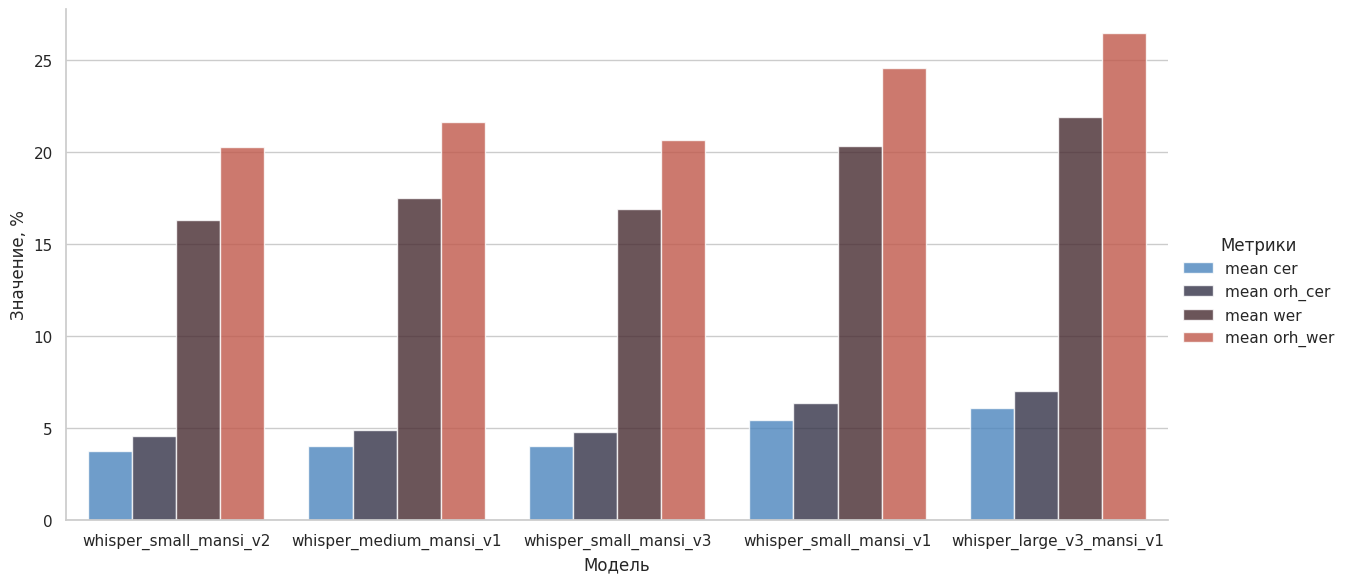

In [18]:
sns.set_theme(style="whitegrid")

data = dataset.drop(columns=['whisper_out', 'label'])
data = data.groupby("model", as_index=False).mean()
data = data.rename(columns={
    'wer': 'mean wer',
    'cer': 'mean cer',
    'orh_wer': 'mean orh_wer',
    'orh_cer': 'mean orh_cer'
})
print(data)

data = data.melt(
    id_vars=["model"],
    var_name="metrics",
    value_name="value"
)

data = data.sort_values("value", ascending=True)

g = sns.catplot(
    data=data, 
    kind="bar",
    x="model", 
    y="value", 
    hue="metrics",
    errorbar=None, 
    palette="icefire", 
    alpha=.8,
    height=6,
    aspect=2
)



g.set_axis_labels("Модель", "Значение, %")
g.legend.set_title("Метрики")
g.savefig("stt mean метрики.png", dpi=600, bbox_inches="tight")

                       model  median wer  median cer  median orh_wer  \
0  whisper_large_v3_mansi_v1   16.666667    3.333333       22.222222   
1    whisper_medium_mansi_v1   12.250000    1.923077       16.666667   
2     whisper_small_mansi_v1   16.666667    2.816901       20.000000   
3     whisper_small_mansi_v2   10.000000    1.612903       15.384615   
4     whisper_small_mansi_v3   11.111111    1.724138       16.666667   

   median orh_cer  
0        4.166667  
1        2.816901  
2        3.744159  
3        2.564103  
4        2.631579  


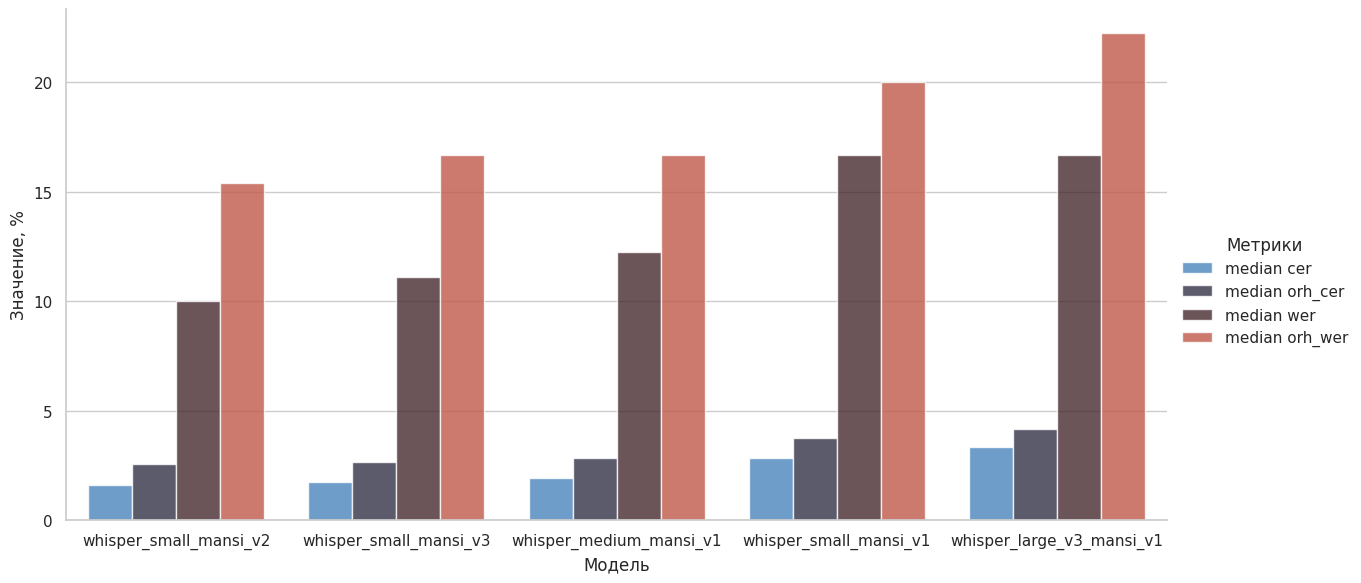

In [19]:
data = dataset.drop(columns=['whisper_out', 'label'])
data = data.groupby("model", as_index=False).median()
data = data.rename(columns={
    'wer': 'median wer',
    'cer': 'median cer',
    'orh_wer': 'median orh_wer',
    'orh_cer': 'median orh_cer'
})
print(data)

data = data.melt(
    id_vars=["model"],
    var_name="metrics",
    value_name="value"
)

data = data.sort_values("value", ascending=True)

g = sns.catplot(
    data=data, 
    kind="bar",
    x="model", 
    y="value", 
    hue="metrics",
    errorbar=None, 
    palette="icefire", 
    alpha=.8,
    height=6,
    aspect=2
)


g.set_axis_labels("Модель", "Значение, %")
g.legend.set_title("Метрики")
g.savefig("stt median метрики.png", dpi=600, bbox_inches="tight")

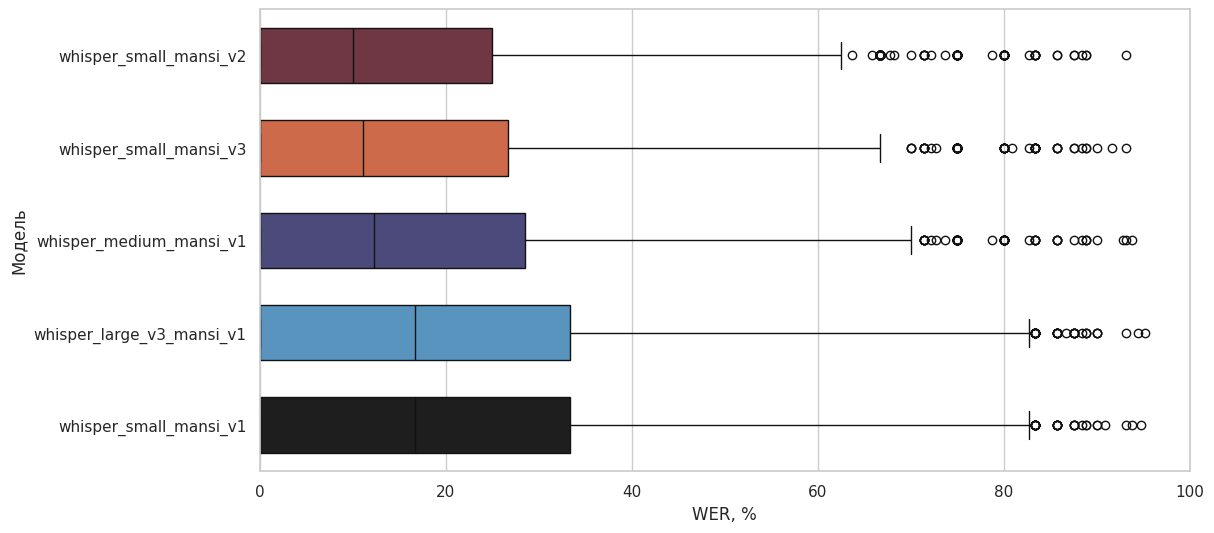

In [20]:
order = (
    dataset.groupby("model")["wer"]
    .median()
    .sort_values(ascending=True)
    .index
)


f, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    dataset, 
    x="wer",
    y="model", 
    hue="model",
    order=order,
    width=.6,
    palette="icefire"
)

ax.set_xlim(0, 100)
ax.set(ylabel="Модель")
ax.set(xlabel="WER, %")

plt.savefig("stt mean распределение ошибок.png", dpi=600, bbox_inches="tight")

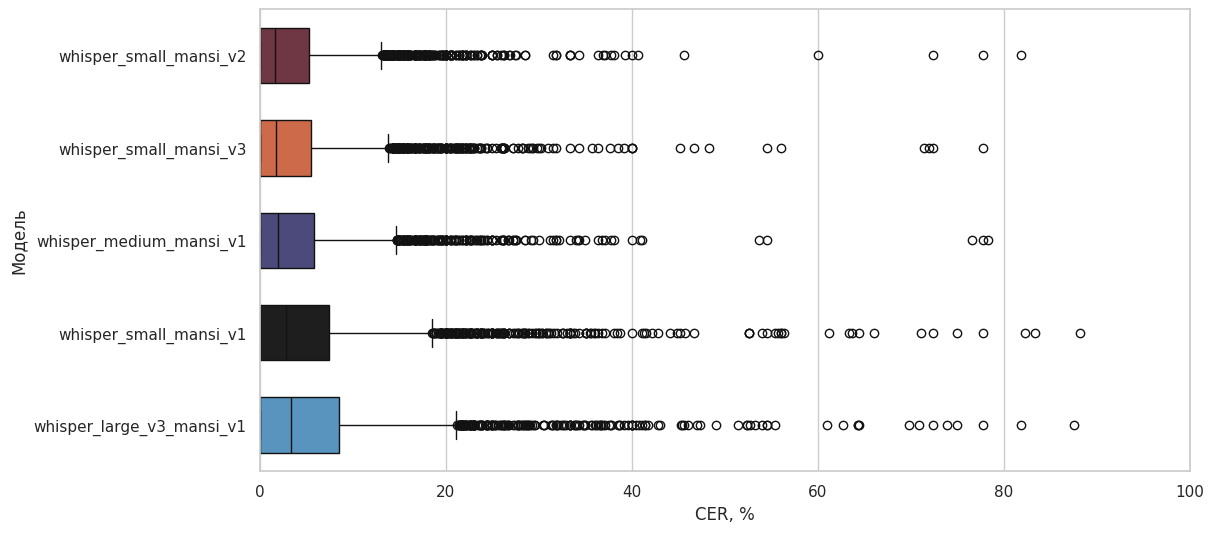

In [21]:
f, ax = plt.subplots(figsize=(12, 6))

order = (
    dataset.groupby("model")["cer"]
    .median()
    .sort_values(ascending=True)
    .index
)

sns.boxplot(
    dataset, 
    x="cer",
    y="model", 
    hue="model",
    order=order,
    width=.6,
    palette="icefire"
)

ax.set_xlim(0, 100)
ax.set(ylabel="Модель")
ax.set(xlabel="CER, %")

plt.savefig("stt median распределение ошибок.png", dpi=600, bbox_inches="tight")

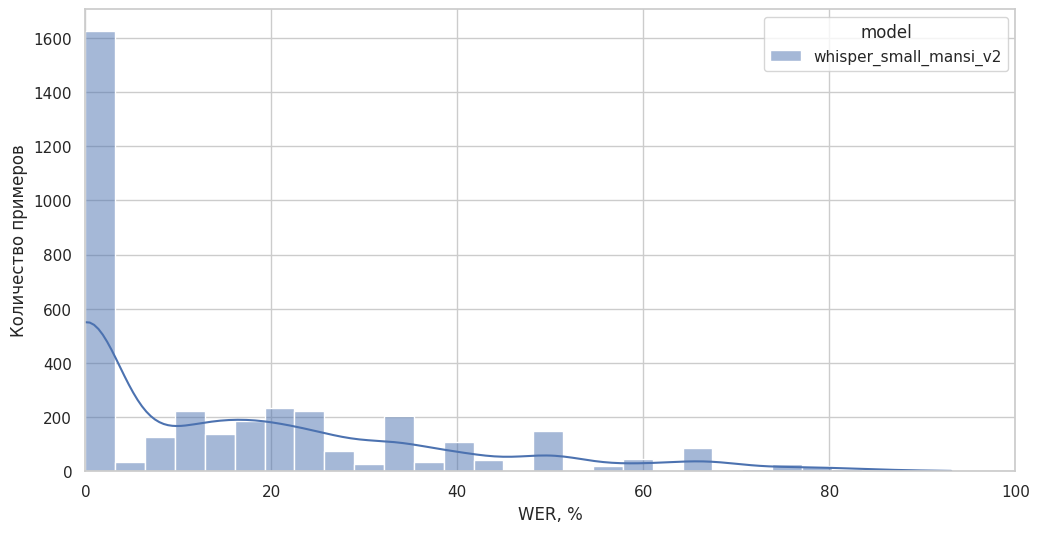

In [22]:
f, ax = plt.subplots(figsize=(12, 6))

data = dataset[dataset['model'] == 'whisper_small_mansi_v2']

sns.histplot(data=data[data['model'] == 'whisper_small_mansi_v2'], x="wer", hue="model", kde=True)

ax.set_xlim(0, 100)
ax.set(ylabel="Количество примеров")
ax.set(xlabel="WER, %")
# plt.legend(title="Тип")

plt.savefig("small_v2 wer.png", dpi=600, bbox_inches="tight")

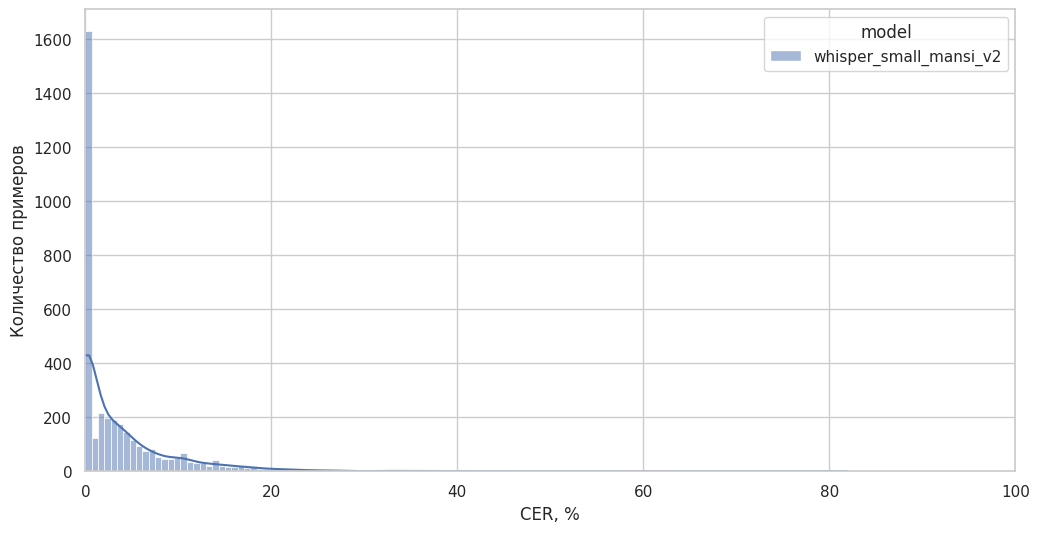

In [23]:
f, ax = plt.subplots(figsize=(12, 6))

data = dataset[dataset['model'] == 'whisper_small_mansi_v2']

sns.histplot(data=data, x="cer", hue="model", kde=True)

ax.set_xlim(0, 100)
ax.set(ylabel="Количество примеров")
ax.set(xlabel="CER, %")
# plt.legend(title="Тип")

plt.savefig("small_v2 cer.png", dpi=600, bbox_inches="tight")

In [24]:
data = pd.DataFrame(columns=['model', 'dataset', 'count'])

data.loc[len(data)] = {"model": "whisper_small_mansi_v1", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "whisper_small_mansi_v1", "dataset": 'TTS Датасет', "count": 12335}


data.loc[len(data)] = {"model": "whisper_large_v3_mansi_v1", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "whisper_large_v3_mansi_v1", "dataset": 'TTS Датасет', "count": 12335}
data.loc[len(data)] = {"model": "whisper_large_v3_mansi_v1", "dataset": 'BONUS Датасет', "count": 13798}


data.loc[len(data)] = {"model": "whisper_medium_mansi_v1", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "whisper_medium_mansi_v1", "dataset": 'TTS Датасет', "count": 12335}
data.loc[len(data)] = {"model": "whisper_medium_mansi_v1", "dataset": 'BONUS Датасет', "count": 13798}


data.loc[len(data)] = {"model": "whisper_small_mansi_v2", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "whisper_small_mansi_v2", "dataset": 'TTS Датасет', "count": 12335}
data.loc[len(data)] = {"model": "whisper_small_mansi_v2", "dataset": 'BONUS Датасет', "count": 13798}


data.loc[len(data)] = {"model": "whisper_small_mansi_v3", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "whisper_small_mansi_v3", "dataset": 'TTS Датасет', "count": 12335}
data.loc[len(data)] = {"model": "whisper_small_mansi_v3", "dataset": 'BONUS Датасет', "count": 13798}
data.loc[len(data)] = {"model": "whisper_small_mansi_v3", "dataset": 'SYNTHETIC Датасет', "count": 73608}

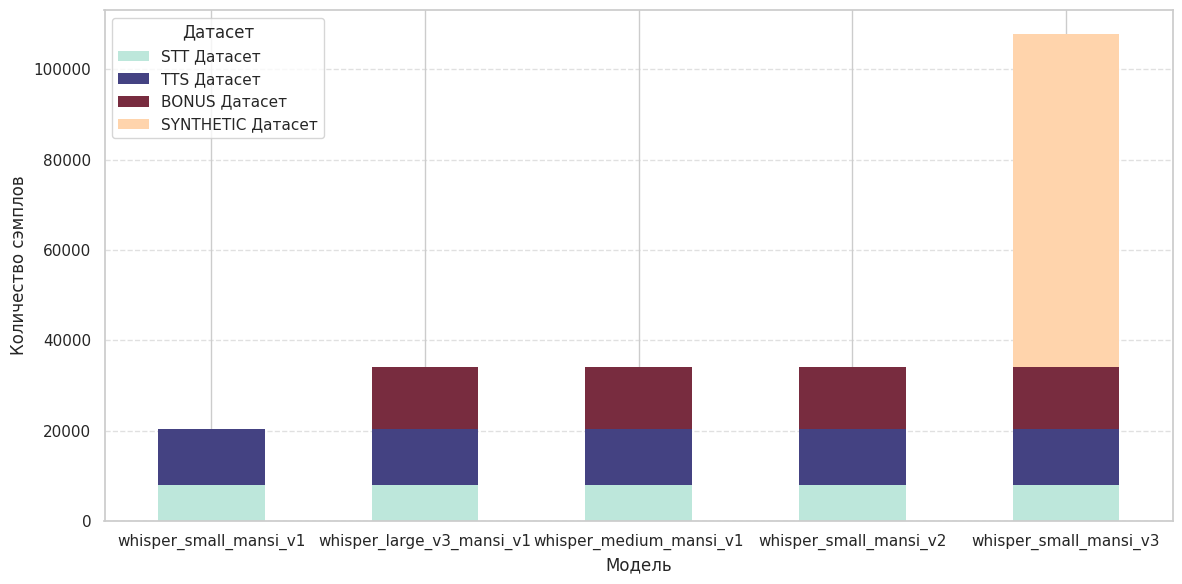

In [25]:
sns.set_theme(style="whitegrid")

pivot = data.pivot(index="model", columns="dataset", values="count")

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

order = ["STT Датасет", "TTS Датасет", "BONUS Датасет", "SYNTHETIC Датасет"]
pivot = pivot[[c for c in order if c in pivot.columns]]

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="icefire",
    edgecolor="none"
)

plt.ylabel("Количество сэмплов", fontsize=12)
plt.xlabel("Модель", fontsize=12)
plt.xticks(rotation=0, ha="center")

plt.legend(title="Датасет")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("распределение данных по stt моделям.png", dpi=600, bbox_inches="tight")

In [26]:
from tensorboard.backend.event_processing import event_accumulator

# path = "models/whisper_small_mansi_v3_synth/tf/events.out.tfevents.1762243761.server.417582.0"
path = "models/whisper_small_mansi_v2/tf/events.out.tfevents.1761151988.server.183071.0"

ea = event_accumulator.EventAccumulator(path)
ea.Reload()

print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['train/loss', 'train/grad_norm', 'train/learning_rate', 'train/epoch', 'eval/loss', 'eval/wer', 'eval/cer', 'eval/orh_wer', 'eval/orh_cer', 'eval/runtime', 'eval/samples_per_second', 'eval/steps_per_second'], 'distributions': [], 'tensors': ['args/text_summary', 'model_config/text_summary'], 'graph': False, 'meta_graph': False, 'run_metadata': []}


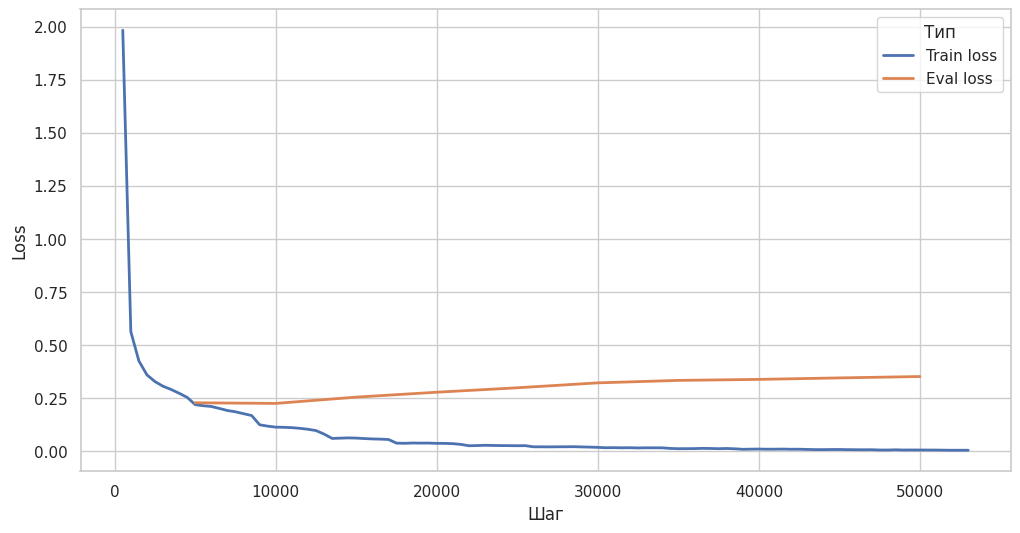

In [27]:
train_loss = ea.Scalars('train/loss')
eval_loss = ea.Scalars('eval/loss')

df = pd.DataFrame([
    {"step": e.step, "value": e.value, "type": "Train loss"} for e in train_loss
] + [
    {"step": e.step, "value": e.value, "type": "Eval loss"} for e in eval_loss
])

f, ax = plt.subplots(figsize=(12, 6))

sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x="step", y="value", hue="type", linewidth=2)

ax.set(ylabel="Loss")
ax.set(xlabel="Шаг")
plt.legend(title="Тип")

plt.savefig("small_v2 loss.png", dpi=600, bbox_inches="tight")

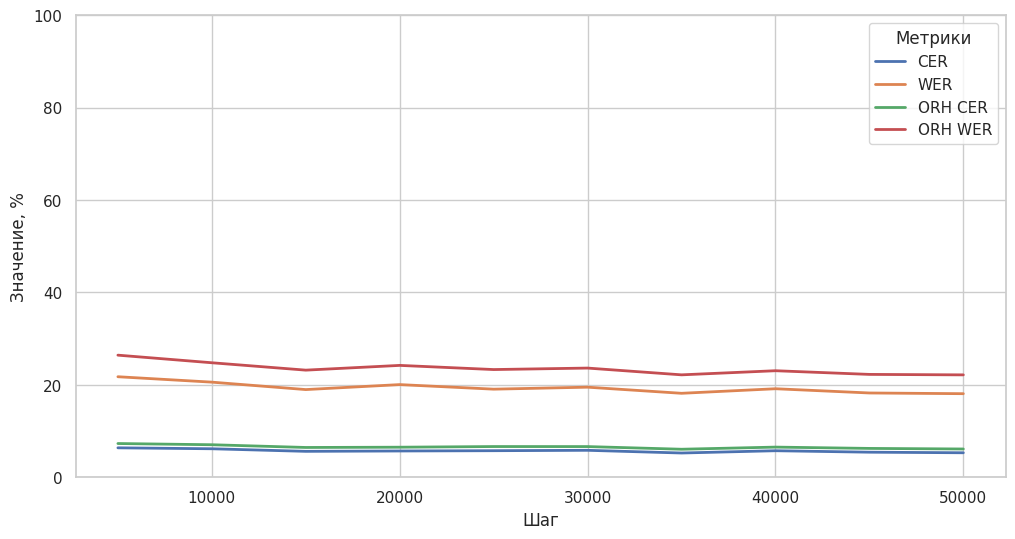

In [28]:
eval_cer= ea.Scalars('eval/cer')
eval_wer= ea.Scalars('eval/wer')
eval_orh_cer= ea.Scalars('eval/orh_cer')
eval_orh_wer= ea.Scalars('eval/orh_wer')

df = pd.DataFrame([
    {"step": e.step, "value": e.value, "type": "CER"} for e in eval_cer
] + [
    {"step": e.step, "value": e.value, "type": "WER"} for e in eval_wer
] + [
    {"step": e.step, "value": e.value, "type": "ORH CER"} for e in eval_orh_cer
] + [
    {"step": e.step, "value": e.value, "type": "ORH WER"} for e in eval_orh_wer
])

f, ax = plt.subplots(figsize=(12, 6))

sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x="step", y="value", hue="type", linewidth=2)

ax.set_ylim(0, 100)
ax.set(ylabel="Значение, %")
ax.set(xlabel="Шаг")
plt.legend(title="Метрики")

plt.savefig("small_v2 метрики.png", dpi=600, bbox_inches="tight")